In [ ]:
./-
The problem is to analyze commodity prices for various commodities using the commodity
prices dataset. The goal is to leverage Python, data science techniques, statistical analysis
and data modeling. Perform all necessary steps to get the key insights from the data"""

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, normaltest, ttest_ind


In [ ]:

File = '/content/commodity_prices.csv'
data = pd.read_csv(File, parse_dates=['date'])


In [ ]:
data

,Unnamed: 0,date,oil_brent,oil_dubai,coffee_arabica,coffee_robustas,tea_columbo,tea_kolkata,tea_mombasa,sugar_eu,sugar_us,sugar_world
0,1,1960-01-01,1.63,1.63,0.940900,0.696864,0.930301,1.121401,1.037400,0.122356,0.116845,0.066600
1,2,1960-02-01,1.63,1.63,0.946900,0.688707,0.930301,1.121401,1.037400,0.122356,0.119049,0.067900
2,3,1960-03-01,1.63,1.63,0.928100,0.688707,0.930301,1.121401,1.037400,0.122356,0.121254,0.068300
3,4,1960-04-01,1.63,1.63,0.930300,0.684519,0.930301,1.121401,1.037400,0.122356,0.123459,0.068100
4,5,1960-05-01,1.63,1.63,0.920000,0.690692,0.930301,1.121401,1.037400,0.122356,0.121254,0.068300
...,...,...,...,...,...,...,...,...,...,...,...,...
751,752,2022-08-01,98.60,97.75,5.917861,2.417366,4.210000,3.538154,2.360000,0.330773,0.782199,0.393525
752,753,2022-09-01,90.16,90.63,5.897138,2.455065,4.490000,3.153198,2.360000,0.323621,0.770956,0.390659
753,754,2022-10-01,93.13,90.59,5.292852,2.270979,4.135621,2.833112,2.457500,0.320943,0.762578,0.386911
754,755,2022-11-01,91.07,86.28,4.715462,2.041258,3.831528,2.849979,2.490000,0.332993,0.792340,0.407414


In [ ]:
#1. What is the maximum price of Robusta coffee ?
print(data.columns)
max_price_robusta = data['coffee_robustas'].max()
print(f"Maximum price of Robusta coffee: ${max_price_robusta:.2f}")


Index(['Unnamed: 0', 'date', 'oil_brent', 'oil_dubai', 'coffee_arabica',
       'coffee_robustas', 'tea_columbo', 'tea_kolkata', 'tea_mombasa',
       'sugar_eu', 'sugar_us', 'sugar_world'],
      dtype='object')
Maximum price of Robusta coffee: $6.88


In [ ]:
#2.What is the 75th percentile of sugar prices in the European Union (EU)?

percentile_75 = data['sugar_eu'].quantile(0.75)
print(f"75th percentile of sugar prices in the EU: ${percentile_75:.2f}")

75th percentile of sugar prices in the EU: $0.57


In [ ]:
#3. What is the skewness of the price distribution for Arabica coffee?

arabica_skewness = skew(data['coffee_arabica'].dropna())
print(f"Skewness of Arabica coffee prices: {arabica_skewness:.2f}")


Skewness of Arabica coffee prices: 0.59


In [ ]:
#4.Is the distribution of sugar prices in the US signicantly different from a normal distribution?
stat, p_value = normaltest(data['sugar_us'].dropna())

if p_value < 0.05:
    print("Sugar prices in the US are significantly different from a normal distribution.")
else:
    print("Sugar prices in the US are not significantly different from a normal distribution.")


Sugar prices in the US are not significantly different from a normal distribution.


In [ ]:
"""5.How many times does the price of Dubai oil exceed the price of Brent oil by a certain
threshold $10 ?"""
exceed_count = (data['oil_dubai'] - data['oil_brent'] > 10).sum()
print(f"Dubai oil prices exceeded Brent oil by $10 on {exceed_count} occasions.")



Dubai oil prices exceeded Brent oil by $10 on 0 occasions.


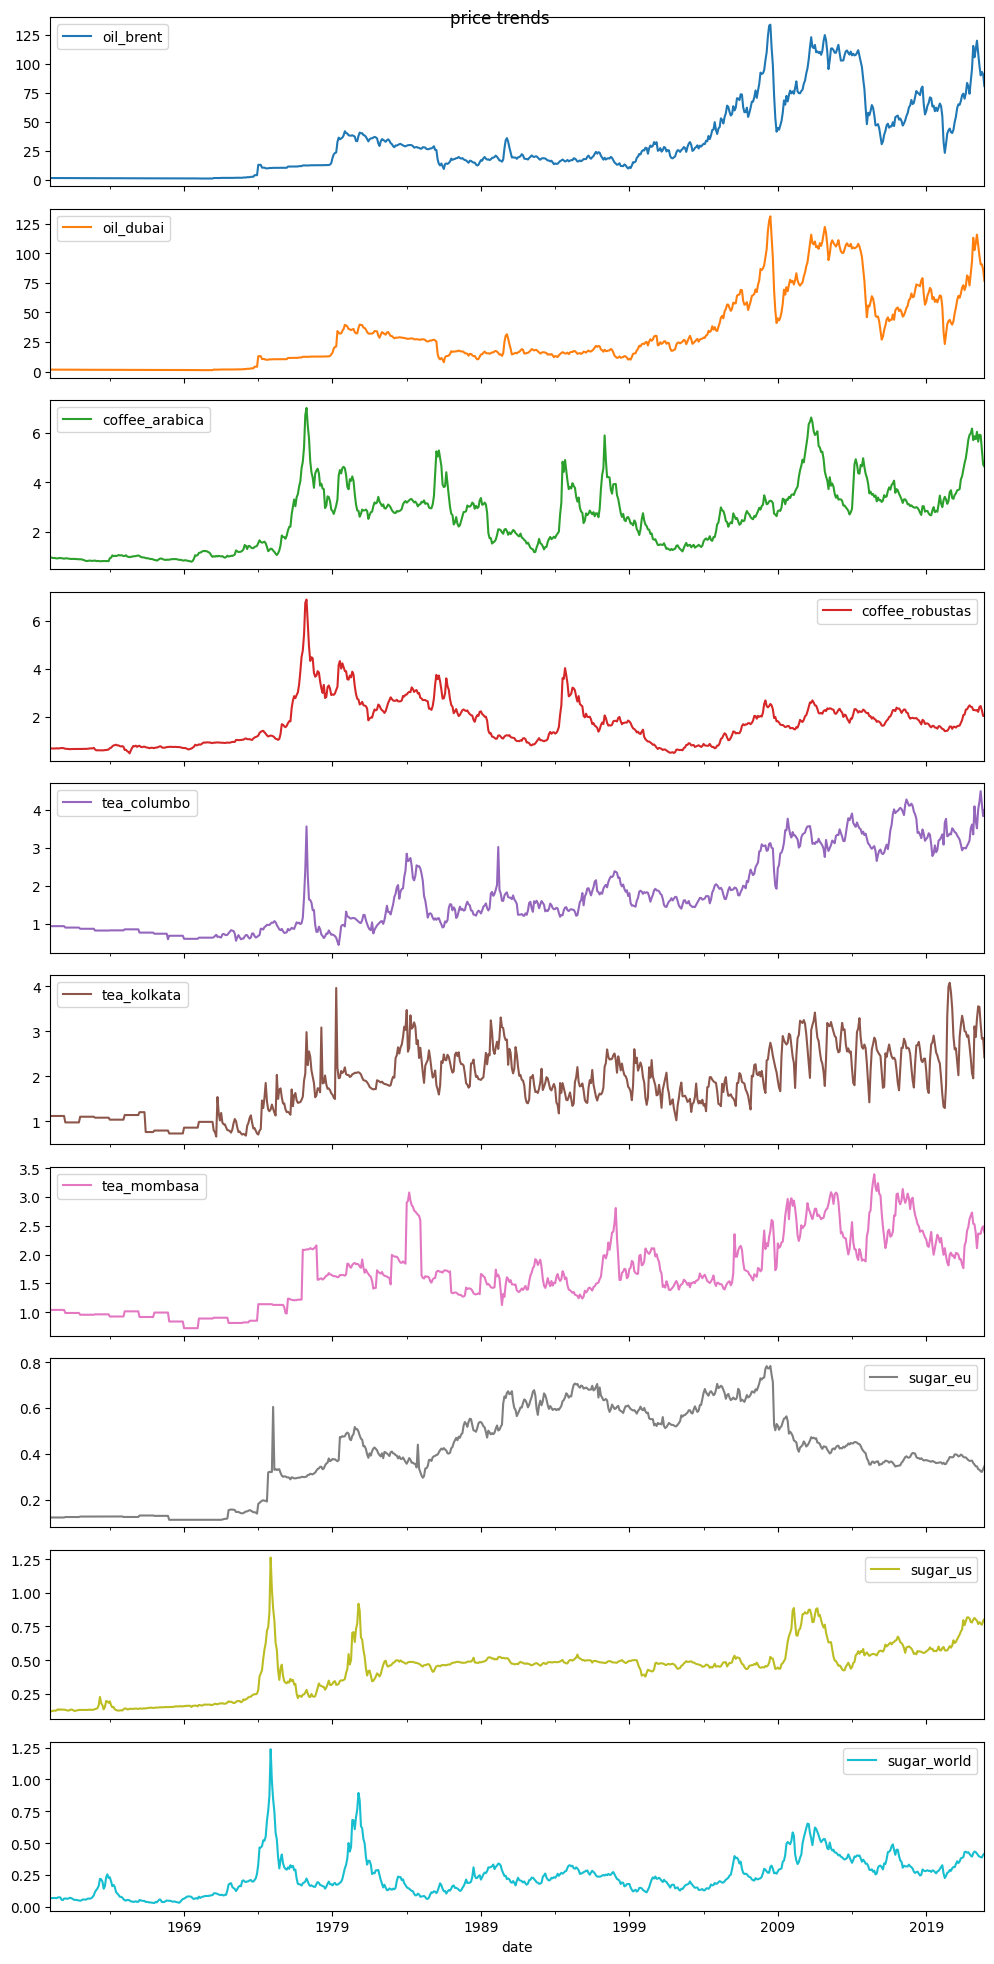

In [ ]:
#6. What is the overall price trend for each commodity ?
data.set_index('date', inplace=True)
commodities = ['oil_brent', 'oil_dubai', 'coffee_arabica', 'coffee_robustas',
               'tea_columbo', 'tea_kolkata', 'tea_mombasa', 'sugar_eu',
               'sugar_us', 'sugar_world']
data[commodities].plot(subplots=True, figsize=(10, 20), title='price trends')
plt.tight_layout()
plt.show()


In [ ]:
#7.Which commodity experienced the highest price fluctuations during the observed period?
price_fluctuations = data[commodities].std()
most_fluctuating_commodity = price_fluctuations.idxmax()
print(f"The commodity with the highest price fluctuations is: {most_fluctuating_commodity}")


The commodity with the highest price fluctuations is: oil_brent


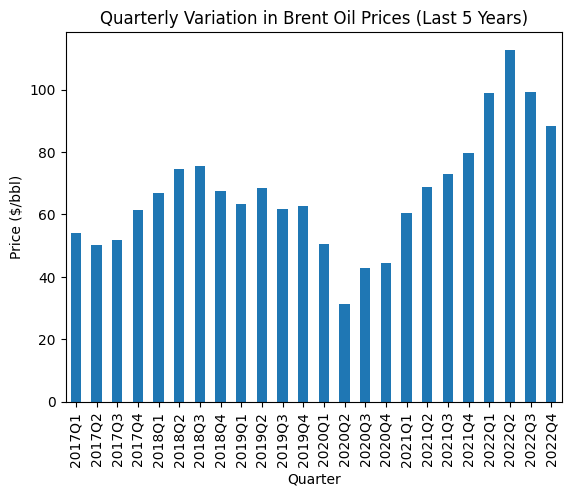

In [ ]:
#8. How has brent oil prices vary on a quarterly basis since the last five years?
data['Quarter'] = data.index.to_period('Q')
brent_quarterly = data[data.index.year >= 2017].groupby('Quarter')['oil_brent'].mean()
brent_quarterly.plot(kind='bar', title='Quarterly Variation in Brent Oil Prices (Last 5 Years)')
plt.ylabel('Price ($/bbl)')
plt.show()



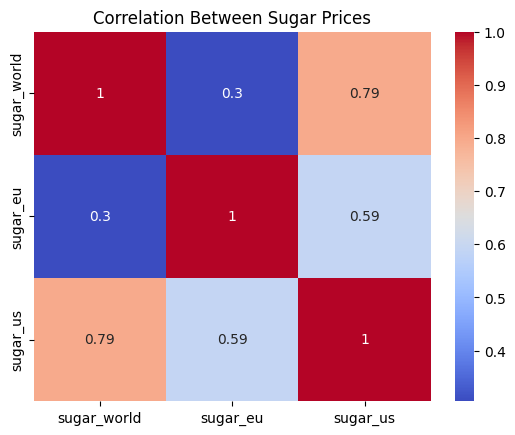

In [ ]:
#9.Is there a correlation between global sugar prices and the prices of EU sugar and US sugar?
correlations = data[['sugar_world', 'sugar_eu', 'sugar_us']].corr()
sns.heatmap(correlations, annot=True, cmap='coolwarm')
plt.title('Correlation Between Sugar Prices')
plt.show()


In [ ]:
"""10.Is there a signicant difference in the distribution of sugar prices between Europe (EU) and
the United States (US)?"""
stat, p_value = ttest_ind(data['sugar_eu'].dropna(), data['sugar_us'].dropna())
if p_value < 0.05:
    print("There is a significant difference in the distribution of sugar prices between EU and US.")
else:
    print("There is no significant difference in the distribution of sugar prices between EU and US.")


There is a significant difference in the distribution of sugar prices between EU and US.


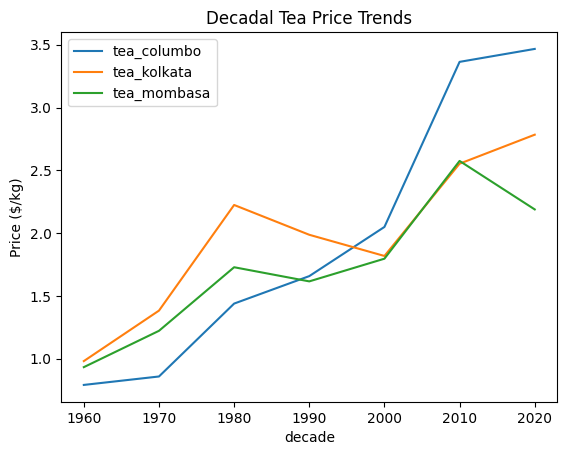

In [ ]:
#How have the prices of tea from columbo, kolkata, and mombasa varied over the decades?
data['decade'] = (data.index.year // 10) * 10
tea_prices = data[['tea_columbo', 'tea_kolkata', 'tea_mombasa']].groupby(data['decade']).mean()
tea_prices.plot(kind='line', title='Decadal Tea Price Trends')
plt.ylabel('Price ($/kg)')
plt.show()



In [ ]:
#Which commodity shows the highest volatility in price on a yearly basis?

yearly_std = data.groupby(data.index.year)[commodities].std().mean()
most_volatile_commodity = yearly_std.idxmax()
print(f"The most volatile commodity yearly is: {most_volatile_commodity}")

The most volatile commodity yearly is: oil_brent


In [ ]:
#How did the 2008 financial crisis affect the prices of commodities?


crisis_period = data[(data.index.year >= 2007) & (data.index.year <= 2009)]
crisis_means = crisis_period[commodities].mean()
normal_means = data[commodities].mean()
impact = (crisis_means - normal_means) / normal_means * 100
print("Percentage change in commodity prices during 2008 financial crisis:")
print(impact)

Percentage change in commodity prices during 2008 financial crisis:
oil_brent          136.511595
oil_dubai          138.918599
coffee_arabica      16.129752
coffee_robustas     13.349375
tea_columbo         58.394632
tea_kolkata         19.250942
tea_mombasa         27.692968
sugar_eu            56.498061
sugar_us            13.696189
sugar_world         25.461848
dtype: float64


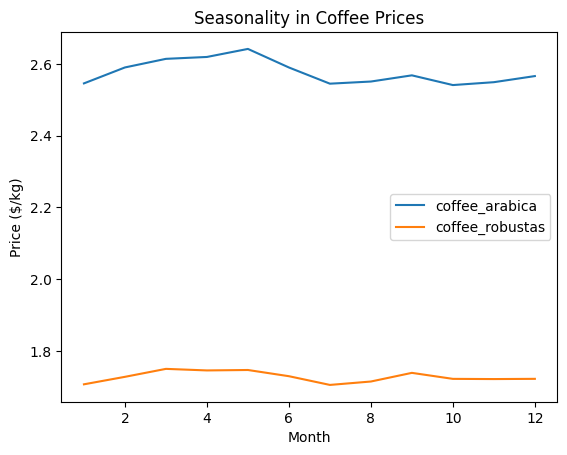

In [ ]:
#Do coffee prices exhibit seasonal trends?

data['Month'] = data.index.month
coffee_seasonality = data.groupby('Month')[['coffee_arabica', 'coffee_robustas']].mean()
coffee_seasonality.plot(kind='line', title='Seasonality in Coffee Prices')
plt.ylabel('Price ($/kg)')
plt.xlabel('Month')
plt.show()

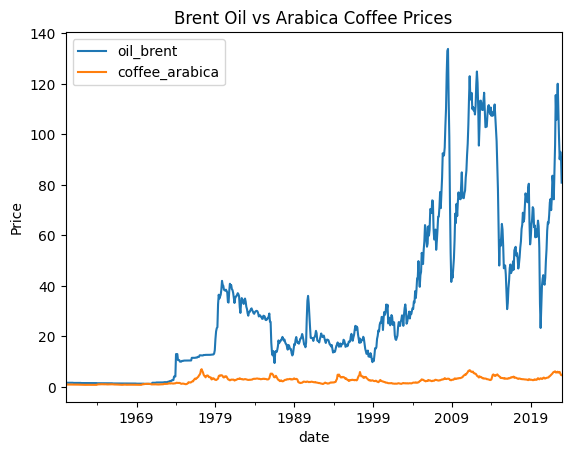

In [ ]:
#5.How do prices of Brent oil compare with Arabica coffee over time?

data[['oil_brent', 'coffee_arabica']].plot(title='Brent Oil vs Arabica Coffee Prices')
plt.ylabel('Price')
plt.show()

In [ ]:
#When did each commodity experience its highest price?

extreme_prices = {commodity: data[commodity].idxmax() for commodity in commodities}
print("Dates of highest prices for each commodity:")
for commodity, date in extreme_prices.items():
    print(f"{commodity}: {date.date()}")

Dates of highest prices for each commodity:
oil_brent: 2008-07-01
oil_dubai: 2008-07-01
coffee_arabica: 1977-04-01
coffee_robustas: 1977-04-01
tea_columbo: 2022-09-01
tea_kolkata: 2020-08-01
tea_mombasa: 2015-07-01
sugar_eu: 2008-07-01
sugar_us: 1974-11-01
sugar_world: 1974-11-01


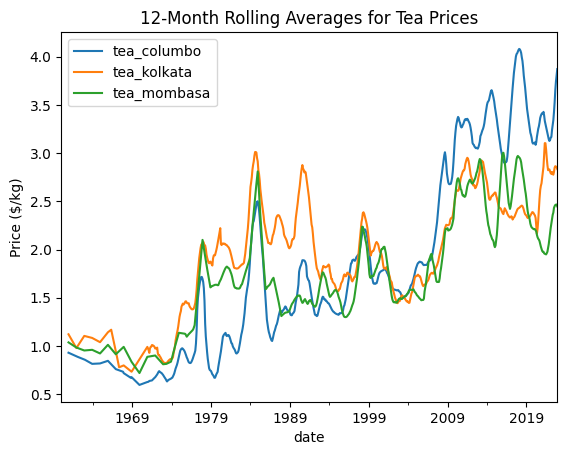

In [ ]:

#What are the 12-month rolling averages for tea prices?


rolling_avg = data[['tea_columbo', 'tea_kolkata', 'tea_mombasa']].rolling(window=12).mean()
rolling_avg.plot(title='12-Month Rolling Averages for Tea Prices')
plt.ylabel('Price ($/kg)')
plt.show()

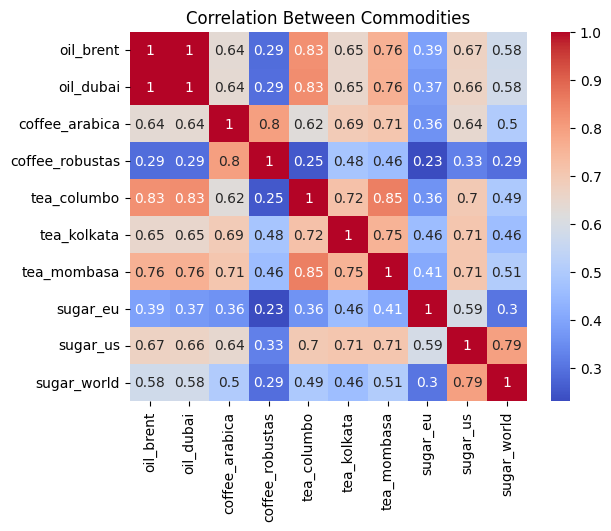

In [ ]:
#Correlation Heatmap
What is the overall correlation between all commodities?


corr_matrix = data[commodities].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Between Commodities')
plt.show()

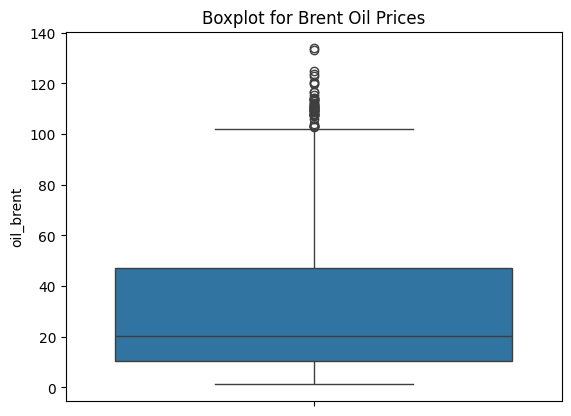

In [ ]:
#Are there any significant outliers in Brent oil prices?

sns.boxplot(data['oil_brent'])
plt.title('Boxplot for Brent Oil Prices')
plt.show()

In [ ]:
#What is the average price ratio of Dubai oil to Brent oil?

price_ratio = (data['oil_dubai'] / data['oil_brent']).mean()
print(f"Average price ratio of Dubai oil to Brent oil: {price_ratio:.2f}")

Average price ratio of Dubai oil to Brent oil: 0.96


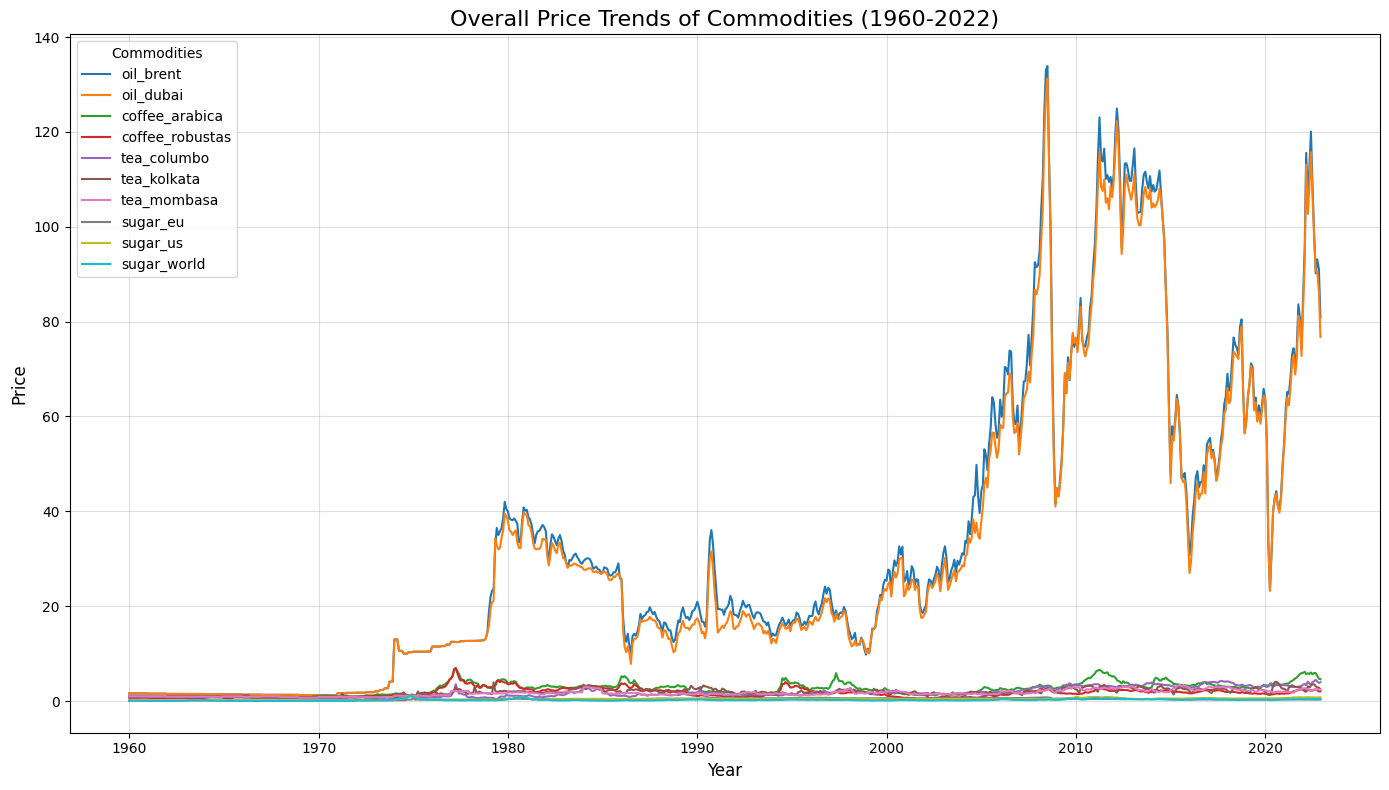

In [ ]:
# Plot all commodities on the same graph
plt.figure(figsize=(14, 8))

commodities = ['oil_brent', 'oil_dubai', 'coffee_arabica', 'coffee_robustas',
               'tea_columbo', 'tea_kolkata', 'tea_mombasa', 'sugar_eu',
               'sugar_us', 'sugar_world']

for commodity in commodities:
    plt.plot(data.index, data[commodity], label=commodity)

plt.title('Overall Price Trends of Commodities (1960-2022)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.legend(title="Commodities", fontsize=10)
plt.grid(alpha=0.4)
plt.tight_layout()

plt.show()
